# Initial visualization of hinging magnetic microrobots

### This notebook is to set up the initial visualization of the hinge-connected magnetic microrobots.

### Introduction

For this project, we attempt to simulate the folding of hinge-connected magnetic microrobots. Our experimental system consists of particles printed by two-photon lithography comprising cubes connected by hinges, where changing the orientation of the hinges allows for three-dimensional folding built from rotations about each hinge's degree of freedom. We apply ferromagnetic patches to our particles, such that the dipole-dipole interactions between the residual dipole moments in the patches cause conformational changes of the particles. 

These particles could be used for biomedical purposes in areas such as drug delivery. However, such applications often require specific folded states. Our microrobots are fabricated using top-down methods, which makes prediction of final folding from initial structure difficult. The goal of this simulation is to predict final conformation probabilities from initial structure to allow for better characterization and application-based fabrication.

In this Jupyter notebook, we walk through the code necessary to simulate this folding process. We examine folding in two dimensions for initial simplicity. We implement two methods of simulation: greedy descent and Monte Carlo. Both methods involve energy minimization, where the energy between two patches is calculated with the following formula:

\begin{equation}
E = \frac{\mu_0}{4\pi}\left(\frac{|\vec{m}|}{2 l}\right)^2\left[\frac{1}{|\vec{r_{13}}|} - \frac{1}{|\vec{r_{14}}|} - \frac{1}{|\vec{r_{23}}|} + \frac{1}{|\vec{r_{24}}|}\right].
\end{equation}

The total energy is calculated by summing over the patch-patch energies for all patch pairs. Note that we are approximating each patch as a dipole.

For greedy descent, we go through each hinge, rotate by a random angle, and store the energy change. Then, we only accept the single hinge movement that yielded the lowest energy. Repeating this until steric hindrance renders favorable moves impossible yields a state in an energy minimum.

For Monte Carlo, we implement the standard Metropolis acceptance procedure. We pick a random hinge and a random angle. Then, all negative-energy moves are accepted, and each positive-energy move is accepted with a probability proportional to the Boltzmann factor for that energy. This allows for the overcoming of energy barriers.

We perform clustering by final state hinge angles in N-dimensional space, where N is the number of hinges. Comparing the clusters across methods reveals that our process is relatively deterministic. 

The remainder of this notebook will walk through our process for simulating this folding.

### Imports

In [ ]:
import numpy as np  # Numerical operations and array manipulations
import matplotlib.pyplot as plt  # Plotting and data visualization
import pandas as pd  # Data structures for handling data (e.g., DataFrame)
import visualization_Functions as vis # our functions for simulation

### Generating a sequence

First, we set up the shape dictionary, which will keep track of all parameters associated with each unit (currently cubes/squares) in the particle.

In [2]:
# The setup is as follows:
# shapes = {'shape 1': ['s', shapeLength, spacingFromPrevious, spacingVariability, patch_dict = {'patch 1':[location, length, edgeOffset], 'patch 2': [location2, length2, offset2]}]}

shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0],'patch 2': ['bottom right', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}]}

Now, we need to generate the sequence, which gives us informational arrays about the structure of shapes, hinges, etc.

In [3]:
hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)

Finally, we need to plot the sequence

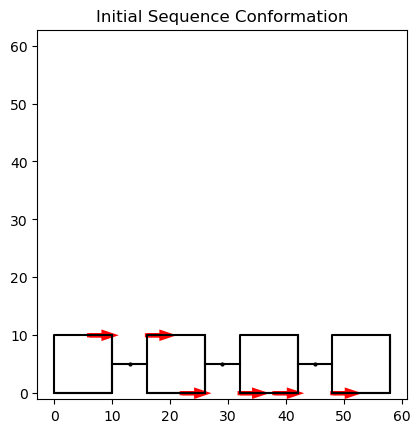

In [4]:
vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

Count the number of shapes. This function is essential for determining if the sequence overlaps itself during folding. If a different number of polygons is counted at any point that is different from the number calculated here, we know that there is overlap in the sequence

In [5]:
polycount = vis.count_shapes(shape_arr)
print(polycount)

4


In [6]:
overlap = vis.check_overlap(shape_arr, polycount)
print(overlap)

False


### Moving a hinge

This next code is not necessary to run full simulations, but is included here for demonstration purposes, showing how the sequence moves. The general algorithm is: translate hinge to origin, rotate everything to the right of hinge using multiplication by the rotation matrix, translate the hinge back to its position before the move. As an example here, hinge 0 will be manipulated

Move hinge to origin:

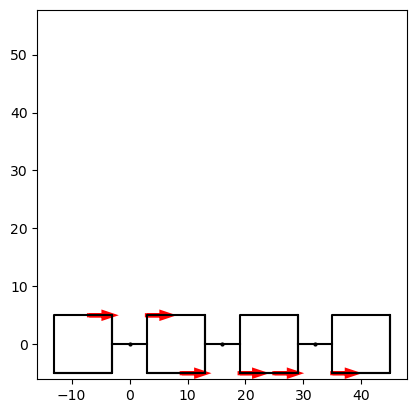

In [7]:
hingechoice = 0 # choose the hinge to rotate
patch_arr_new, shape_arr_new,hinge_loc_new  = vis.translate_to_origin(patch_arr, shape_arr, hinge_loc, hingechoice) # move hinge to origin
vis.shapeplots(shape_arr_new, linelist, hinge_loc_new, mag_vecs = patch_arr_new)

Rotate by set angle:

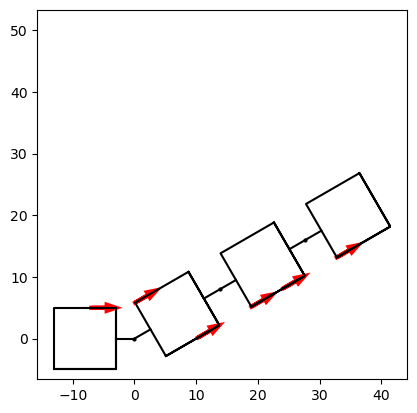

In [8]:
angle = 30
patch_arr_new, shape_arr_new, hinge_vec_new, hinge_loc_new = vis.rotate(patch_arr_new, shape_arr_new, linelist, hinge_vec, hinge_loc_new, hingechoice, angle, patch_num)
vis.shapeplots(shape_arr_new, linelist, hinge_loc_new, mag_vecs = patch_arr_new)

Translate back to original location:

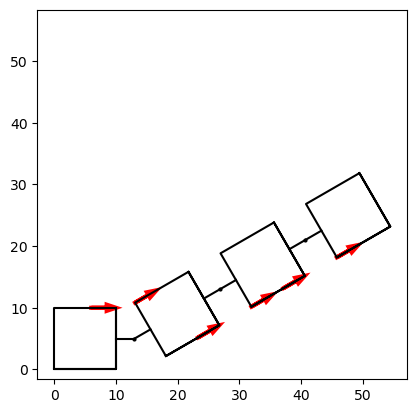

In [9]:
patch_arr_new,shape_arr_new,hinge_loc_new = vis.translate_back(patch_arr_new,shape_arr_new,hinge_loc_new)
vis.shapeplots(shape_arr_new, linelist, hinge_loc_new, mag_vecs = patch_arr_new)

##### This whole operation can be done altogether using the function below:

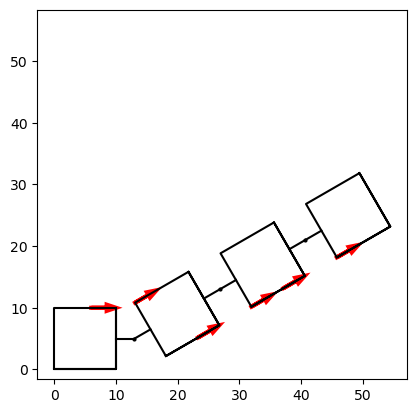

In [10]:
hingechoice = 0
angle = 30
patch_arr_new, shape_arr_new, hinge_vec_new, hinge_loc_new = vis.rotate_once(patch_arr,shape_arr,linelist,hinge_vec,hingechoice, hinge_loc, angle, patch_num)
vis.shapeplots(shape_arr_new, linelist, hinge_loc_new, mag_vecs = patch_arr_new)


### Magnetics and energies

Define the magnetization (from experiments) and setup a magnetization vector

In [11]:
# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

Initialize arrays used in the energy calculation of each sequence.

In [12]:
mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

Test calculate the energy in Joules

In [13]:
E = vis.energy_math(patch_arr,mask_arr, v_xmat, h_xmat, v_ymat, h_ymat,Ml_mat)
print(E)

-4.151777868204307e-14


This calculation has been confirmed by hand!

Test calculate the energy in Joules of the rotated hinge

In [14]:
E2 = vis.energy_math(patch_arr_new,mask_arr, v_xmat, h_xmat, v_ymat, h_ymat,Ml_mat)
print(E2)

-5.042511444758076e-14


This calculation has been confirmed by hand!

In [15]:
# Print the difference to compare energy change to kT (roughly 10^-21)
print(E2-E)

-8.907335765537687e-15


I created a cutoff energy minimum in case the patches ever touch to avoid a singularity at r=0. The code below is testing that the cutoff works and the energy is continuous:

Text(0, 0.5, 'E')

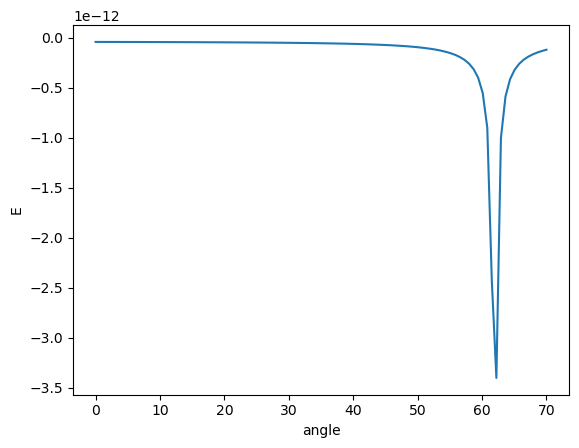

In [16]:
angles = np.linspace(0,70,100)
hingechoice = 0
E = []
for angle in angles:
    patch_arr_new, shape_arr_new, hinge_vec_new, hinge_loc_new = vis.rotate_once(patch_arr,shape_arr,linelist,hinge_vec,hingechoice, hinge_loc, angle, patch_num)
    E.append(vis.energy_math(patch_arr_new,mask_arr, v_xmat, h_xmat, v_ymat, h_ymat,Ml_mat))

plt.plot(angles,E)
plt.xlabel("angle")
plt.ylabel("E")
# plt.xlim(61.925,61.94)
# plt.ylim(-1.5e-9,-1.4e-9)

### Simulation (greedy descent)

Starting with our three-hinge conformation above, we perform greedy descent to arrive at a final conformation

In [17]:
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
patch_arr_sim, shape_arr_sim, hinge_vec_sim, hinge_loc_sim, current_energy_sim = vis.simulate_greedyDescent(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, tol=0)

Current energy:  -7.052842736609784e-11  Joules


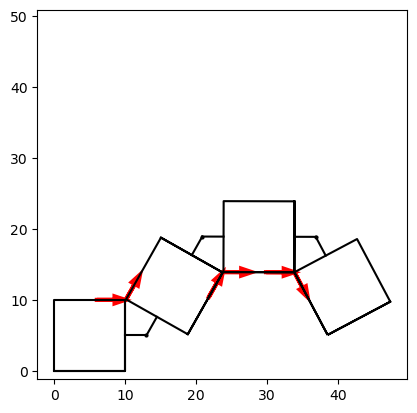

Energy is:  -7.052842736609784e-11


In [18]:
vis.shapeplots(shape_arr_sim, linelist,hinge_loc_sim, mag_vecs = patch_arr_sim) # plot the resulting final state
print("Energy is: ", vis.energy_math(patch_arr_sim,mask_arr, v_xmat, h_xmat, v_ymat, h_ymat,Ml_mat))

We can now simulate many times for clustering

In [21]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges, final_es = vis.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, tol=0, plot=False)

Current energy:  -1.1309292025319478e-10  Joules
Current energy:  -4.189934929982897e-12  Joules
Current energy:  -4.593694130870192e-12  Joules
Current energy:  -3.9524040889401735e-12  Joules
Current energy:  -5.068341402177047e-12  Joules
Current energy:  -8.358900736178697e-12  Joules
Current energy:  -3.8964207684792093e-11  Joules
Current energy:  -5.153973555155698e-11  Joules
Current energy:  -1.1966482011148742e-11  Joules
Current energy:  -1.5028961919944462e-11  Joules
Current energy:  -4.0391684533990146e-11  Joules
Current energy:  -1.39017091695528e-11  Joules
Current energy:  -2.085983102963539e-11  Joules
Current energy:  -5.074969606168522e-12  Joules
Current energy:  -1.1027119353019066e-10  Joules
Current energy:  -3.4936079111821948e-12  Joules
Current energy:  -1.471335734178514e-11  Joules
Current energy:  -1.1090035216823522e-11  Joules
Current energy:  -2.1734608312900324e-11  Joules
Current energy:  -2.5057110544828686e-11  Joules
Current energy:  -2.0223422648

Clustering: we plot two different methods (Silhouette and Davies-Bouldin scores) to determine optimal cluster count. A higher value of the Silhouette score is better, while a lower value of the Davies-Bouldin score is better. We take the maximum optimal cluster number yielded by the two scores.

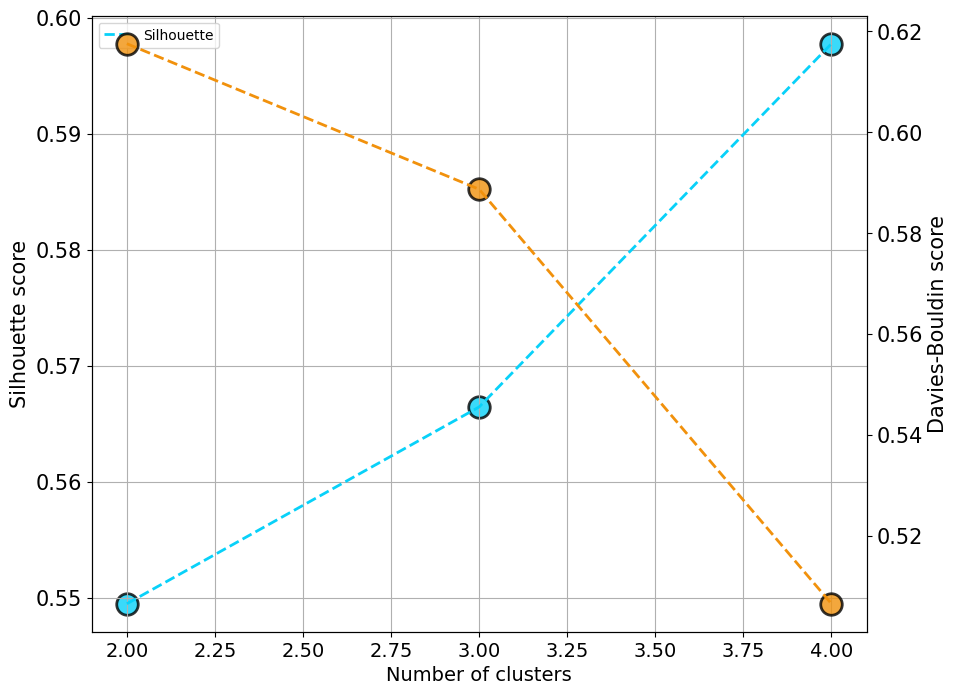

In [28]:
cluster_max = 5
states = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber = vis.cluster_num(final_hinges,cluster_max,states, Plot = True)

We can plot the clusters for our three-hinge system in 3D space:

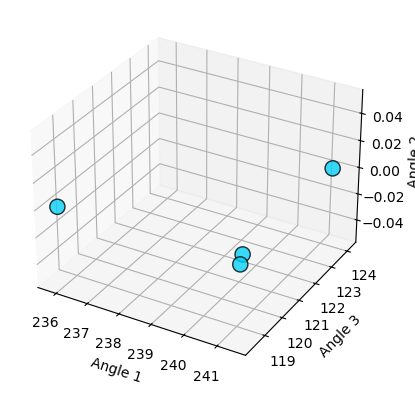

In [29]:
clustercenters, cluster_labels, clusternumber = vis.min_cluster_centers(final_hinges, clusternumber, final_es, Plots = '3D')

Note that the variations in angles are minimal, so we are likely creating clusters from very little differences in the data. We can group the clusters by their energy minima to see the frequency of each cluster:

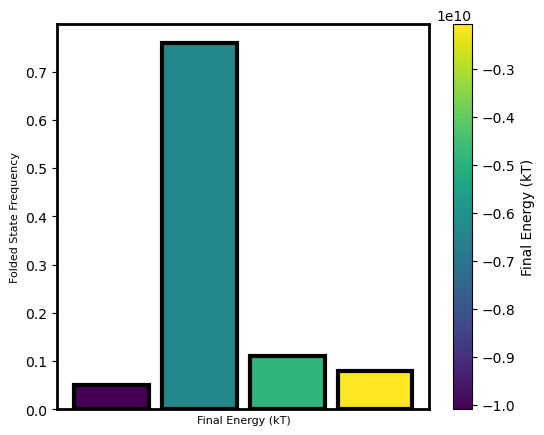

In [31]:
clusternumbers, cluster_count, cluster_prob, energies, ordered_centers, all_stds = vis.cluster_stats(final_hinges, clusternumber, clustercenters, cluster_labels,
                                                                                                    final_es, plot=True)

So, we see that the one energy state is the more likely outcome here, which makes sense. In reality, we're forcing clusters from very little differences in the data. So, let's now examine a more complex system.

### More complex clustering

We now examine a more complicated shape array that could have multiple final conformations

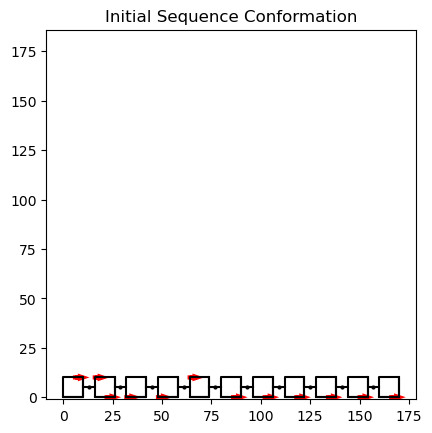

In [32]:
# more complicated shape array
shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}
hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)
vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)


In [33]:
# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

Current energy:  -5.837197249018306e-11  Joules


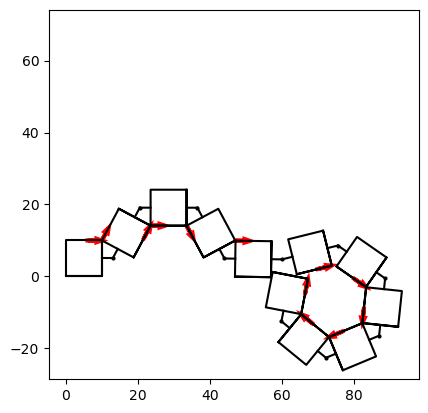

In [35]:
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
patch_arr_sim, shape_arr_sim, hinge_vec_sim, hinge_loc_sim, current_energy_sim = vis.simulate_greedyDescent(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, tol=0)
vis.shapeplots(shape_arr_sim, linelist,hinge_loc_sim, mag_vecs = patch_arr_sim)

In [36]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges, final_es = vis.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, tol=0, plot=False)

Current energy:  -1.0227972660389267e-11  Joules
Current energy:  -1.1889650675921024e-11  Joules
Current energy:  -1.8594033402736012e-11  Joules
Current energy:  -3.391036578845626e-11  Joules
Current energy:  -1.1498447595343237e-10  Joules
Current energy:  -1.0891752577173076e-10  Joules
Current energy:  -2.0357720546367487e-11  Joules
Current energy:  -1.4714623703698212e-11  Joules
Current energy:  -5.459981711916071e-11  Joules
Current energy:  -2.1309550785444567e-10  Joules
Current energy:  -3.447037791333951e-11  Joules
Current energy:  -1.9669614561649783e-11  Joules
Current energy:  -6.378220838081411e-11  Joules
Current energy:  -2.0247372808981705e-11  Joules
Current energy:  -5.2388545608253905e-11  Joules
Current energy:  -2.7946739497432382e-11  Joules
Current energy:  -2.2708835457266458e-11  Joules
Current energy:  -2.5447280782914818e-11  Joules
Current energy:  -5.038952368515353e-11  Joules
Current energy:  -2.976269154411609e-11  Joules
Current energy:  -4.446671

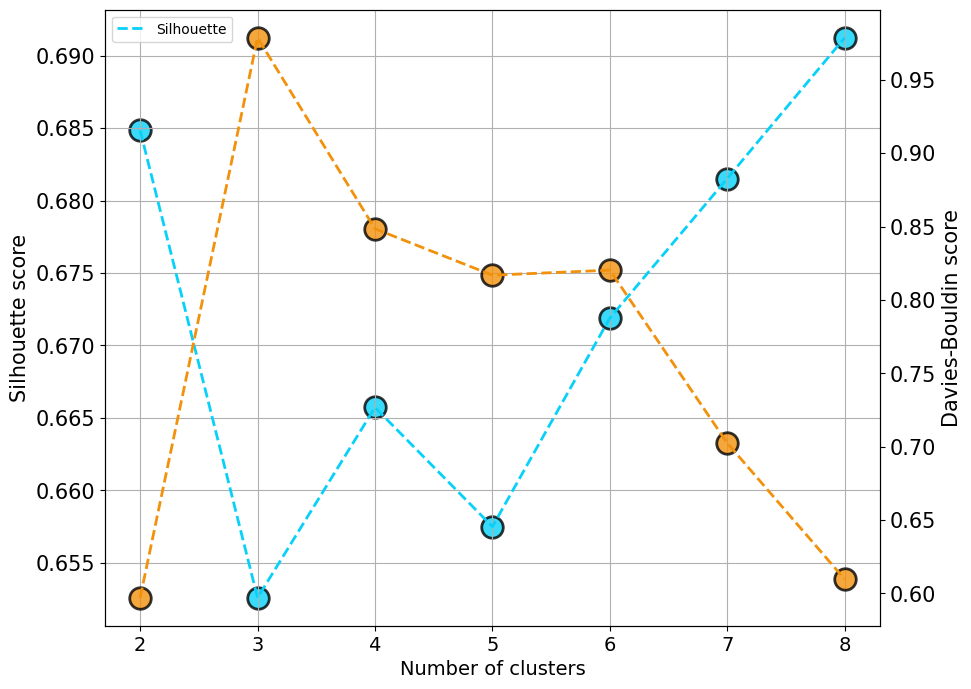

In [49]:
cluster_max = 9
states = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber = vis.cluster_num(final_hinges,cluster_max,states, Plot = True)

In [50]:
clustercenters, cluster_labels, clusternumber = vis.min_cluster_centers(final_hinges, clusternumber, final_es)

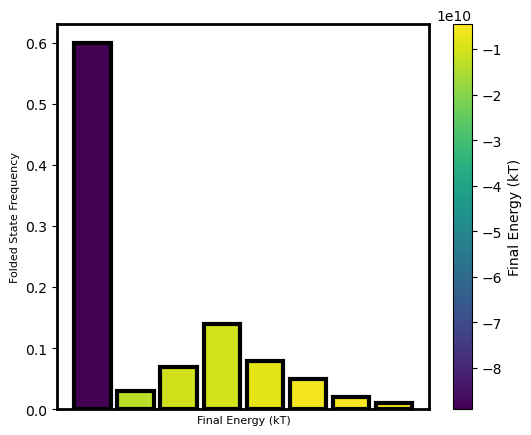

In [51]:
clusternumbers, cluster_count, cluster_prob, energies, ordered_centers, all_stds = vis.cluster_stats(final_hinges, clusternumber, clustercenters, cluster_labels,
                                                                                                    final_es, plot=True)

We see that the most common outcome is by far the lowest energy state. We can compare this energy to the calculated energies for example states to find the conformation that corresponds to this cluster. There are a few higher energy clusters that have comparable energies, which likely means they have similar states. The cluster number could be optimized.

### Monte Carlo

We attempt to incorporate a monte carlo version of the simulation, which allows for unfavorable energy moves with some probability proportional to the energy change relative to kBT.

We start with our simpler conformation:

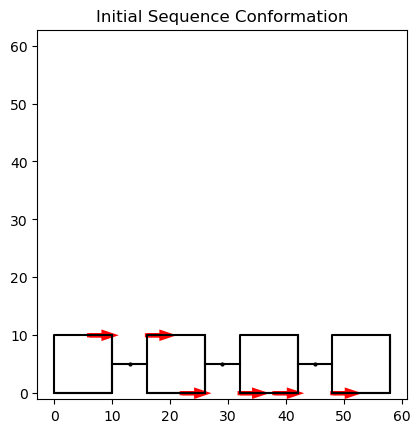

In [52]:
shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0],'patch 2': ['bottom right', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}]}

hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

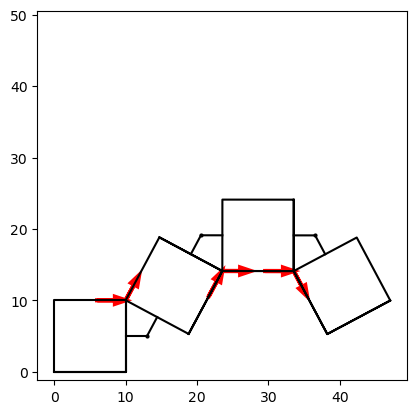

Energy is:  -1.433936143678226e-10


In [53]:
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
patch_arr_sim, shape_arr_sim, hinge_vec_sim, hinge_loc_sim, current_energy_sim = vis.simulate_monteCarlo(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, kBT=4.11e-21)
vis.shapeplots(shape_arr_sim, linelist,hinge_loc_sim, mag_vecs = patch_arr_sim) # plot the resulting final state
print("Energy is: ", vis.energy_math(patch_arr_sim,mask_arr, v_xmat, h_xmat, v_ymat, h_ymat,Ml_mat))

In [54]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges, final_es = vis.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, tol=0, plot=False)

Current energy:  -4.1322344637712995e-11  Joules
Current energy:  -1.835048215323442e-11  Joules
Current energy:  -6.4102671327626735e-12  Joules
Current energy:  -1.3171784332131804e-11  Joules
Current energy:  -1.1615014888374741e-11  Joules
Current energy:  -2.8904430468964332e-11  Joules
Current energy:  -2.9215581347702035e-11  Joules
Current energy:  -5.3583765928487365e-12  Joules
Current energy:  -1.851389566103597e-11  Joules
Current energy:  -3.6396590094971854e-12  Joules
Current energy:  -1.71011145292065e-11  Joules
Current energy:  -2.7741954728007586e-11  Joules
Current energy:  -7.845530201925376e-11  Joules
Current energy:  -2.237092552206275e-11  Joules
Current energy:  -1.504485663077192e-10  Joules
Current energy:  -1.443462458510502e-11  Joules
Current energy:  -4.1099676025546624e-12  Joules
Current energy:  -2.403969666386041e-12  Joules
Current energy:  -4.7331813805086333e-11  Joules
Current energy:  -1.012185485419222e-10  Joules
Current energy:  -9.4972411110

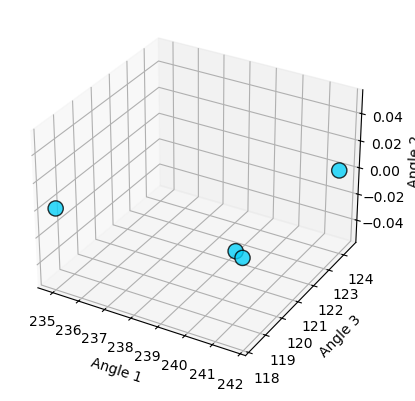

In [55]:
cluster_max = 5
states = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber = vis.cluster_num(final_hinges,cluster_max,states, Plot = False)
clustercenters, cluster_labels, clusternumber = vis.min_cluster_centers(final_hinges, clusternumber, final_es,Plots='3D')


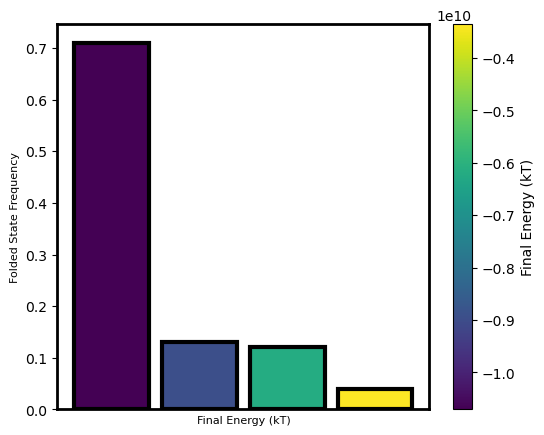

In [56]:
clusternumbers, cluster_count, cluster_prob, energies, ordered_centers, all_stds = vis.cluster_stats(final_hinges, clusternumber, clustercenters, cluster_labels,
                                                                                                    final_es, plot=True)

So, the results are very similar to our previous method, suggesting that the conformation in this case is very deterministic. We now attempt the more complicated conformation.

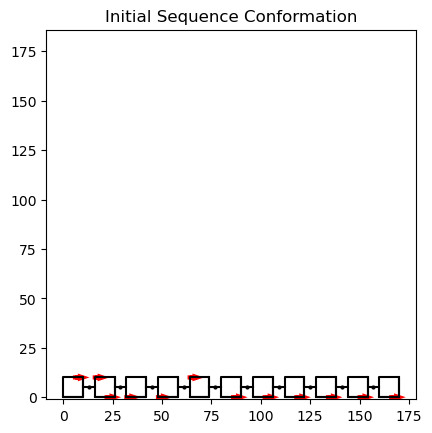

In [57]:
shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

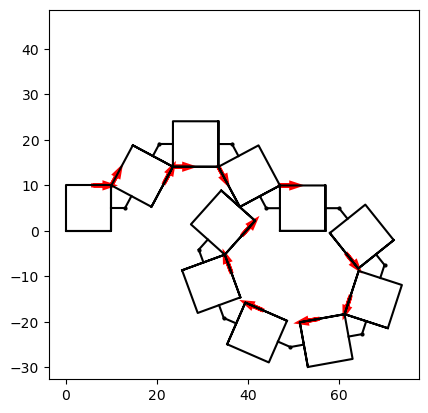

In [58]:
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
patch_arr_sim, shape_arr_sim, hinge_vec_sim, hinge_loc_sim, current_energy_sim = vis.simulate_monteCarlo(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, kBT=4.11e-21)
vis.shapeplots(shape_arr_sim, linelist,hinge_loc_sim, mag_vecs = patch_arr_sim) # plot the resulting final state

In [59]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges, final_es = vis.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, tol=0, plot=False)

Current energy:  -1.1918506332836556e-11  Joules
Current energy:  -1.4026795560804269e-11  Joules
Current energy:  -1.4356833545615237e-10  Joules
Current energy:  -1.1529726440339535e-11  Joules
Current energy:  -1.444457816547572e-11  Joules
Current energy:  -5.4221477491088904e-11  Joules
Current energy:  -3.528492657111432e-11  Joules
Current energy:  -1.2798360730063951e-11  Joules
Current energy:  -8.50332904937818e-11  Joules
Current energy:  -8.634592282506406e-12  Joules
Current energy:  -1.0582173437131924e-11  Joules
Current energy:  -4.240426922871662e-12  Joules
Current energy:  -1.2268098079902674e-11  Joules
Current energy:  -3.422883426368408e-11  Joules
Current energy:  -1.8291515451831374e-11  Joules
Current energy:  -2.1311436877840954e-11  Joules
Current energy:  -4.4669722793810344e-11  Joules
Current energy:  -2.8656155414422374e-11  Joules
Current energy:  -5.6539065199850645e-11  Joules
Current energy:  -1.8016384994874705e-11  Joules
Current energy:  -6.6223184

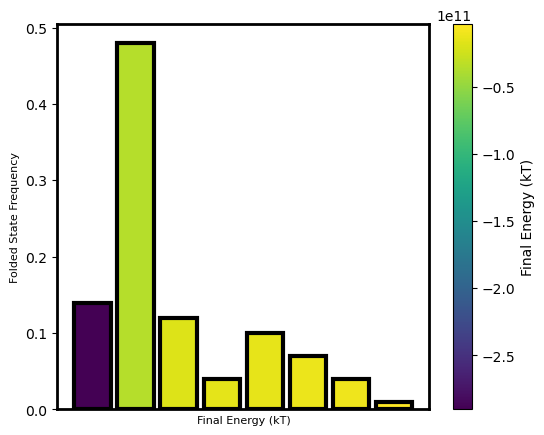

In [62]:
cluster_max = 9
states = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber = vis.cluster_num(final_hinges,cluster_max,states, Plot = False)
clustercenters, cluster_labels, clusternumber = vis.min_cluster_centers(final_hinges, clusternumber, final_es)
clusternumbers, cluster_count, cluster_prob, energies, ordered_centers, all_stds = vis.cluster_stats(final_hinges, clusternumber, clustercenters, cluster_labels,
                                                                                                    final_es, plot=True)

We see that the Monte Carlo method stil yields a large proportion at lower energy with several clusters of various higher energy states. We observe a small very low energy population that is likely a result of Monte Carlo exploring more pathways than greedy descent. However, the general results (and the most likely conformations) appear roughly similar upon analysis, which points to a deterministic system.

### Conclusions

We have seen two methods for simulating the folding of magnetic microrobots. The results for the deterministic greedy descent method were similar to the results for Monte Carlo, which indicates that our system is fairly deterministic. This result makes sense, as the energy scale of our system is many orders of magnitude larger than kBT, so unfavorable moves should hardly ever be accepted in the Monte Carlo process.

In the future, I will look at more simulation methods and compare results of clustering. I aim to implement more physical methods than greedy descent to observe whether we see similar clusters. This analysis would reveal just how deterministic our system really is. 

However, we have made significant progess on this work through this project, and we now have a couple of methods to predict folding of our fabricated system. This informs our initial design, and allows for more practical applications in biomedical areas, such as drug delivery.